<a href="https://www.kaggle.com/code/ahmedfakhar123/ml-48-bagging-intuition-theory-code?scriptVersionId=350120181" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

---
# 🛍️ ML 48 — Bagging | Intuition, Theory & Code

# Importing Libraries

In [1]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier

from sklearn.tree import plot_tree
from mlxtend.plotting import plot_decision_regions

from sklearn.metrics import accuracy_score

# Reading Data

In [2]:
df = pd.read_csv('/kaggle/input/datasets/uciml/iris/Iris.csv',
                usecols=lambda column: column not in ["Id"])
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


# Label Encoding

In [3]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df['Species'] = encoder.fit_transform(df['Species'])

df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [4]:
df = df[df['Species'] != 0][['SepalWidthCm', 'PetalLengthCm', 'Species']]
df.head()

,SepalWidthCm,PetalLengthCm,Species
50,3.2,4.7,1
51,3.2,4.5,1
52,3.1,4.9,1
53,2.3,4.0,1
54,2.8,4.6,1


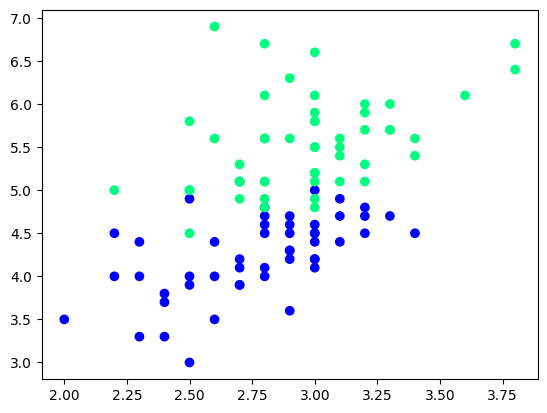

In [5]:
plt.scatter(df['SepalWidthCm'], df['PetalLengthCm'], c=df['Species'], cmap='winter')
plt.show()

# Bagging from Scratch

In [6]:
# Taking only 10 rows for training
df = df.sample(100)
df_train = df.iloc[:60,:].sample(10)
df_val = df.iloc[60:80,:].sample(5)
df_test = df.iloc[80:,:].sample(5)

In [7]:
df_train

,SepalWidthCm,PetalLengthCm,Species
50,3.2,4.7,1
63,2.9,4.7,1
97,2.9,4.3,1
136,3.4,5.6,2
149,3.0,5.1,2
82,2.7,3.9,1
95,3.0,4.2,1
52,3.1,4.9,1
103,2.9,5.6,2
86,3.1,4.7,1


In [8]:
df_val

,SepalWidthCm,PetalLengthCm,Species
135,3.0,6.1,2
140,3.1,5.6,2
126,2.8,4.8,2
100,3.3,6.0,2
77,3.0,5.0,1


In [9]:
df_test

,SepalWidthCm,PetalLengthCm,Species
51,3.2,4.5,1
105,3.0,6.6,2
142,2.7,5.1,2
123,2.7,4.9,2
104,3.0,5.8,2


In [10]:
X_test = df_val.drop(columns=['Species'])
y_test = df_val.Species

In [11]:
y_test

135    2
140    2
126    2
100    2
77     1
Name: Species, dtype: int64

# Case 1 - Bagging

In [12]:
# Data for Tree 1
df_bag1 = df_train.sample(8, replace=True)

X = df_bag1.drop(columns=['Species'])
y = df_bag1.Species

df_bag1

,SepalWidthCm,PetalLengthCm,Species
95,3.0,4.2,1
63,2.9,4.7,1
82,2.7,3.9,1
52,3.1,4.9,1
149,3.0,5.1,2
149,3.0,5.1,2
149,3.0,5.1,2
95,3.0,4.2,1


In [13]:
def evaluate(clf, X, y):
    clf.fit(X,y)
    plot_tree(clf)
    plt.show()
    plot_decision_regions(X.values, y.values, clf=clf, legend=2)
    y_pred = clf.predict(X_test)
    print(accuracy_score(y_test,y_pred))

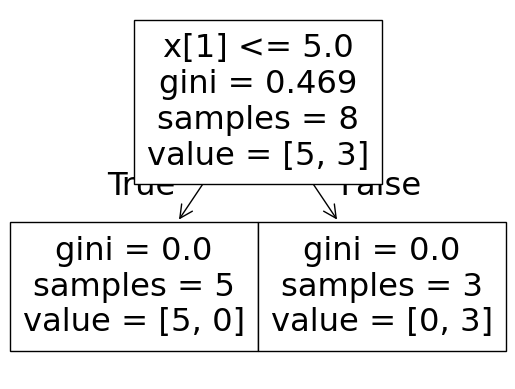

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


0.8


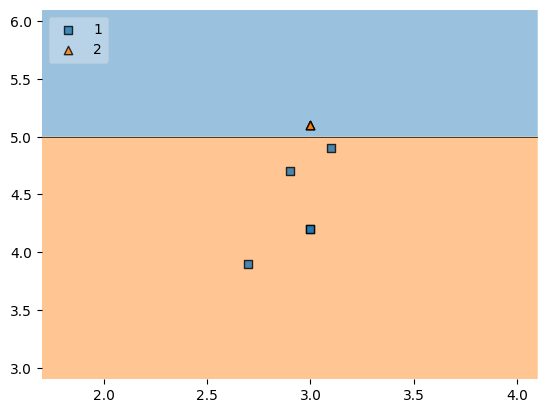

In [14]:
dt_bag1 = DecisionTreeClassifier()
evaluate(dt_bag1, X, y)

In [15]:
# Data for Tree 1
df_bag2 = df_train.sample(8,replace=True)

# Fetch X and y
X = df_bag2.drop(columns=['Species'])
y = df_bag2.Species

# print df_bag
df_bag2

,SepalWidthCm,PetalLengthCm,Species
97,2.9,4.3,1
63,2.9,4.7,1
86,3.1,4.7,1
63,2.9,4.7,1
103,2.9,5.6,2
52,3.1,4.9,1
149,3.0,5.1,2
86,3.1,4.7,1


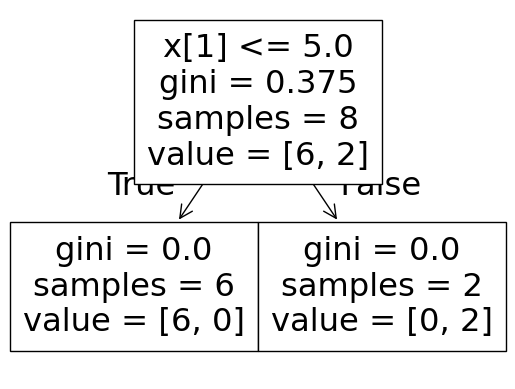

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


0.8


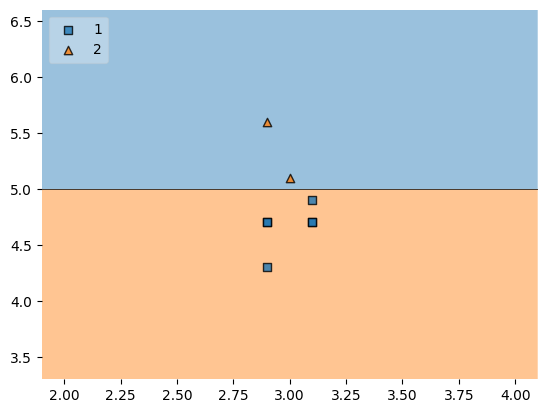

In [16]:
dt_bag2 = DecisionTreeClassifier()
evaluate(dt_bag2,X,y)

In [17]:
# Data for Tree 3
df_bag3 = df_train.sample(8,replace=True)

# Fetch X and y
X = df_bag3.drop(columns=['Species'])
y = df_bag3.Species

# print df_bag
df_bag3

,SepalWidthCm,PetalLengthCm,Species
103,2.9,5.6,2
95,3.0,4.2,1
136,3.4,5.6,2
136,3.4,5.6,2
86,3.1,4.7,1
82,2.7,3.9,1
149,3.0,5.1,2
97,2.9,4.3,1


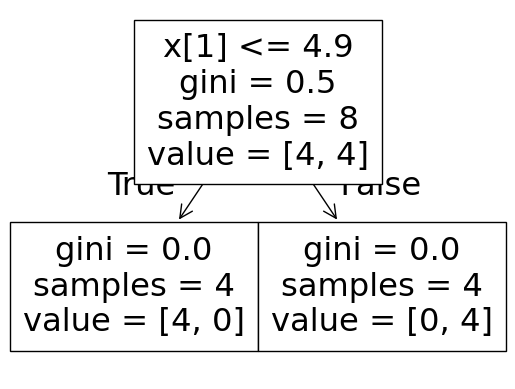

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


0.6


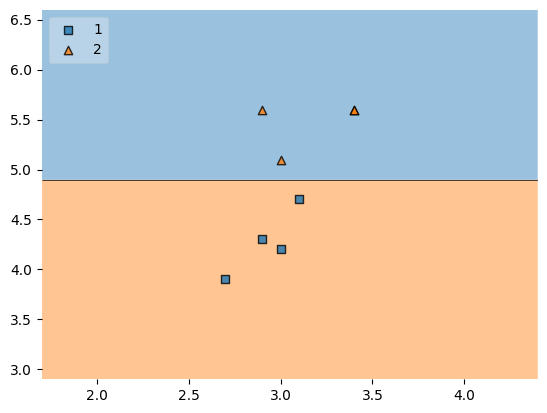

In [18]:
dt_bag3 = DecisionTreeClassifier()
evaluate(dt_bag3,X,y)

## Predict

In [19]:
print("Predictor 1",dt_bag1.predict(np.array([2.2,5.0]).reshape(1,2)))
print("Predictor 2",dt_bag2.predict(np.array([2.2,5.0]).reshape(1,2)))
print("Predictor 3",dt_bag3.predict(np.array([2.2,5.0]).reshape(1,2)))

Predictor 1 [1]
Predictor 2 [1]
Predictor 3 [2]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


# Case 2: Pasting

In [20]:
# Row sampling without replacement
df_train

,SepalWidthCm,PetalLengthCm,Species
50,3.2,4.7,1
63,2.9,4.7,1
97,2.9,4.3,1
136,3.4,5.6,2
149,3.0,5.1,2
82,2.7,3.9,1
95,3.0,4.2,1
52,3.1,4.9,1
103,2.9,5.6,2
86,3.1,4.7,1


In [21]:
df_train.sample(8)

,SepalWidthCm,PetalLengthCm,Species
63,2.9,4.7,1
50,3.2,4.7,1
97,2.9,4.3,1
103,2.9,5.6,2
149,3.0,5.1,2
95,3.0,4.2,1
86,3.1,4.7,1
136,3.4,5.6,2


# Case 3: Random Subspaces

In [22]:
df1 = pd.read_csv('/kaggle/input/datasets/uciml/iris/Iris.csv',
                usecols=lambda column: column not in ["Id"])
df1 = df1.sample(10)
df1.head(10)

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
69,5.6,2.5,3.9,1.1,Iris-versicolor
98,5.1,2.5,3.0,1.1,Iris-versicolor
121,5.6,2.8,4.9,2.0,Iris-virginica
14,5.8,4.0,1.2,0.2,Iris-setosa
102,7.1,3.0,5.9,2.1,Iris-virginica
128,6.4,2.8,5.6,2.1,Iris-virginica
65,6.7,3.1,4.4,1.4,Iris-versicolor
49,5.0,3.3,1.4,0.2,Iris-setosa
54,6.5,2.8,4.6,1.5,Iris-versicolor
41,4.5,2.3,1.3,0.3,Iris-setosa


In [23]:
df1.sample(2,replace=True,axis=1)

,SepalLengthCm,SepalLengthCm
69,5.6,5.6
98,5.1,5.1
121,5.6,5.6
14,5.8,5.8
102,7.1,7.1
128,6.4,6.4
65,6.7,6.7
49,5.0,5.0
54,6.5,6.5
41,4.5,4.5


# Case 4: Random Patches

In [24]:
df1

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
69,5.6,2.5,3.9,1.1,Iris-versicolor
98,5.1,2.5,3.0,1.1,Iris-versicolor
121,5.6,2.8,4.9,2.0,Iris-virginica
14,5.8,4.0,1.2,0.2,Iris-setosa
102,7.1,3.0,5.9,2.1,Iris-virginica
128,6.4,2.8,5.6,2.1,Iris-virginica
65,6.7,3.1,4.4,1.4,Iris-versicolor
49,5.0,3.3,1.4,0.2,Iris-setosa
54,6.5,2.8,4.6,1.5,Iris-versicolor
41,4.5,2.3,1.3,0.3,Iris-setosa


In [25]:
df1.sample(8,replace=True).sample(2,replace=True,axis=1)

,PetalWidthCm,Species
102,2.1,Iris-virginica
128,2.1,Iris-virginica
98,1.1,Iris-versicolor
102,2.1,Iris-virginica
14,0.2,Iris-setosa
121,2.0,Iris-virginica
49,0.2,Iris-setosa
14,0.2,Iris-setosa


# Bagging in `scikit-learn`

In [26]:
from sklearn.datasets import make_classification
from sklearn.metrics import accuracy_score
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split